In [1]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
from matplotlib.colors import LinearSegmentedColormap
from numba import njit, prange
from scipy.spatial import cKDTree
from matplotlib.ticker import ScalarFormatter

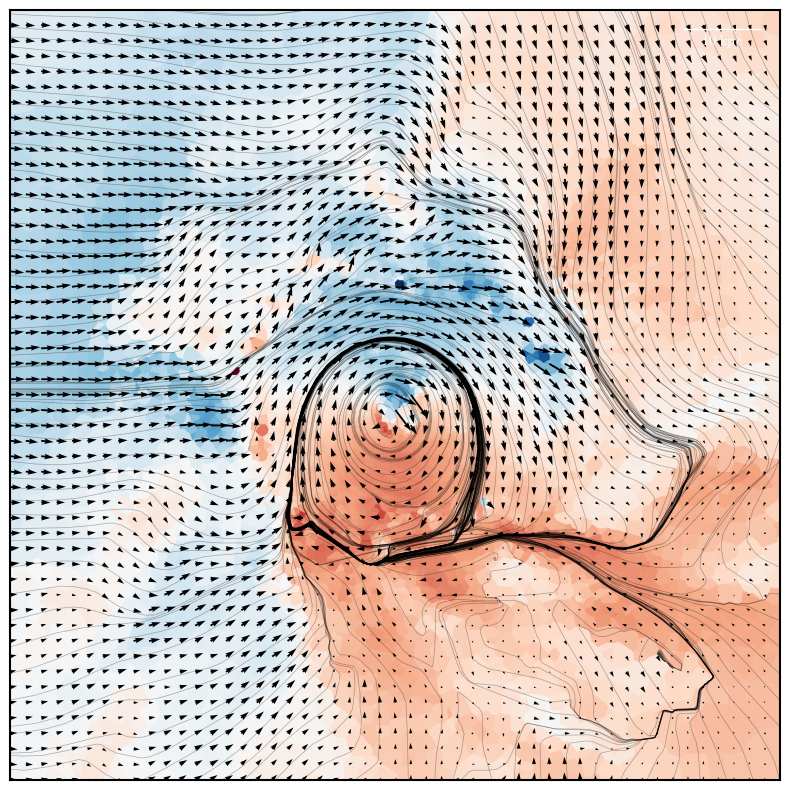

In [7]:
galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[2])

basis_change = (galaxy.gas["Coordinates"][1000:1003] - galaxy.bhs["Coordinates"][0])
transform = galaxy.gas["RotatedCoordinates"][1000:1003]
rotation = (np.linalg.inv(basis_change) @ transform).T


new_rotated = (galaxy.gas["Coordinates"] - galaxy.bhs["Coordinates"][0]) @ rotation.T
# rotated_magneticfield_bulk = galaxy.gas["Velocities"] @ rotation.T

mask = np.linalg.norm(new_rotated, ord=np.inf, axis=-1) < 50
coords = new_rotated[mask]
bulk_magnetic = galaxy.gas["Velocities"][mask] @ rotation.T

# coords[:, [0, 2]] = coords[:, [2, 0]]
# bulk_magnetic[:, [0, 2]] = bulk_magnetic[:, [2, 0]]
# turb_magnetic[:, [0, 2]] = turb_magnetic[:, [2, 0]]
grid_size = 1000
grid = (range(0, grid_size), range(0, grid_size), range(grid_size//2, grid_size//2 + 1))
struct_bulk = nicegalaxy.map_unstructured_to_structured_slice_optimized(coords, bulk_magnetic, grid_size=grid_size, grid=grid)
sieve = 1
Y, X = np.mgrid[0:grid_size:sieve, 0:grid_size:sieve]
U_bulk = struct_bulk[::sieve, ::sieve, 0]
V_bulk = struct_bulk[::sieve, ::sieve, 1]

struct_dens = nicegalaxy.map_unstructured_to_structured_slice_optimized(coords, bulk_magnetic[:, 0], grid_size=grid_size, grid=grid)
fig, ax = plt.subplots(figsize=(8, 8))
cutout_size = 100
scalebar_length = round(cutout_size/10)
scalebar_pixels = scalebar_length/cutout_size * struct_dens.shape[0]
ax.imshow(struct_dens, cmap="RdBu", interpolation=None, origin="lower")
ax.set_yticks([])
ax.set_xticks([])
ax.streamplot(X, Y, U_bulk, V_bulk, density=1, color=(0, 0, 0, 0.3), arrowsize=0, linewidth=0.5, broken_streamlines=False)
sieve = 20
Y, X = np.mgrid[0:grid_size:sieve, 0:grid_size:sieve]
U_bulk = struct_bulk[::sieve, ::sieve, 0]
V_bulk = struct_bulk[::sieve, ::sieve, 1]
ax.quiver(X, Y, U_bulk, V_bulk)
ax.plot([struct_dens.shape[0]*(1 - 1/40) - scalebar_pixels, struct_dens.shape[0]*(1 - 1/40)], [struct_dens.shape[0]*(1 - 1/40), struct_dens.shape[0]*(1 - 1/40)], color='white', linewidth=1)
ax.text(struct_dens.shape[0]*(1 - 1/40) - scalebar_pixels/2, struct_dens.shape[0]*(1 - 1/30), f"{scalebar_length} kpc", ha="center", va="top", color="white")
fig.tight_layout()
fig.show()
# fig.savefig(f"vel-streamlines/{idx}.png", bbox_inches="tight", dpi=500)

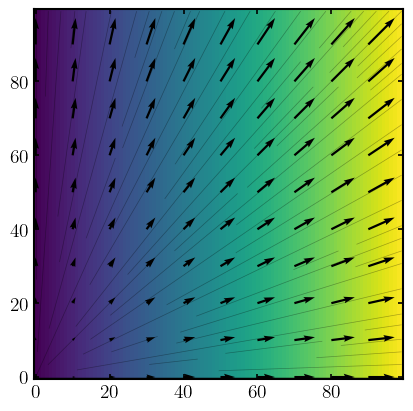

In [15]:
Y, X = np.mgrid[0:100:1, 0:100:1]

plt.imshow(np.abs(X), origin="lower")
plt.streamplot(X, Y, np.abs(X), Y, density=1, color=(0, 0, 0, 0.3), arrowsize=0, linewidth=0.5)
plt.quiver(X[::10, ::10], Y[::10, ::10], np.abs(X)[::10, ::10], (Y)[::10, ::10])

